In [1]:
import gc
import re
import time
from pathlib import Path

import numpy as np
import xarray as xr
from arraylake import Client

try:
    from geopy.geocoders import Nominatim
except ImportError:
    Nominatim = None

# ============================================================
# CONFIG
# ============================================================
TARGET_LAT = 26.4967
TARGET_LON = 80.2413  # 0..360 works fine here too
START_YEAR = 2000
END_YEAR = 2025

CHUNK_SIZE = 12  # Earthmover pressure temporal chunks are 12x12 spatially

REPO_NAME = "earthmover-public/era5"
BRANCH = "main"
GROUP = "pressure/temporal"

OUT_BASE = Path("ERA5_DATABASE")
OUT_BASE.mkdir(parents=True, exist_ok=True)

# Variables we want from pressure levels
VARS = ["t", "q", "z"]

# ============================================================
# HELPERS
# ============================================================

def slugify(text: str) -> str:
    text = text.strip().lower()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"[\s_-]+", "_", text)
    return text[:80] or "site"

def reverse_geocode_place_name(lat: float, lon: float) -> str | None:
    """
    Best-effort reverse geocode. If it fails, return None.
    """
    if Nominatim is None:
        return None

    try:
        geolocator = Nominatim(user_agent="era5_downloader")
        loc = geolocator.reverse((lat, lon), language="en", timeout=20)
        if loc is None:
            return None

        addr = (loc.raw or {}).get("address", {})
        for key in ["city", "town", "village", "municipality", "county", "state", "country"]:
            if addr.get(key):
                return str(addr[key])

        # Fallback to display name if available
        display = (loc.raw or {}).get("display_name")
        if display:
            return str(display).split(",")[0].strip()

    except Exception:
        return None

    return None

def choose_tile_indices(lat_vals: np.ndarray, lon_vals: np.ndarray, target_lat: float, target_lon: float, chunk_size: int = 12):
    """
    Find the nearest grid point, then expand to the full chunk-aligned tile.
    """
    lat_idx = int(np.argmin(np.abs(lat_vals - target_lat)))
    lon_idx = int(np.argmin(np.abs(lon_vals - target_lon)))

    lat0 = (lat_idx // chunk_size) * chunk_size
    lon0 = (lon_idx // chunk_size) * chunk_size

    lat1 = min(lat0 + chunk_size, len(lat_vals))
    lon1 = min(lon0 + chunk_size, len(lon_vals))

    return lat_idx, lon_idx, lat0, lat1, lon0, lon1

def save_metadata(outdir: Path, lat_vals, lon_vals, pressure_levels, target_lat, target_lon,
                  lat_idx, lon_idx, lat0, lat1, lon0, lon1, place_name: str):
    """
    Save one metadata file for the whole site.
    """
    np.savez_compressed(
        outdir / "metadata_pressure.npz",
        place_name=np.array(place_name),
        target_lat=np.array(target_lat, dtype=np.float64),
        target_lon=np.array(target_lon, dtype=np.float64),
        nearest_lat=np.array(lat_vals[lat_idx], dtype=np.float64),
        nearest_lon=np.array(lon_vals[lon_idx], dtype=np.float64),
        lat_idx=np.array(lat_idx, dtype=np.int32),
        lon_idx=np.array(lon_idx, dtype=np.int32),
        lat0=np.array(lat0, dtype=np.int32),
        lat1=np.array(lat1, dtype=np.int32),
        lon0=np.array(lon0, dtype=np.int32),
        lon1=np.array(lon1, dtype=np.int32),
        tile_latitudes=lat_vals[lat0:lat1].astype(np.float32),
        tile_longitudes=lon_vals[lon0:lon1].astype(np.float32),
        pressure_levels=np.asarray(pressure_levels),
    )

def download_year_block(pressure_ds: xr.Dataset, year: int, lat0: int, lat1: int, lon0: int, lon1: int, outfile: Path):
    """
    Download one year for the chosen tile and save it compressed.
    """
    start = f"{year}-01-01"
    end = f"{year}-12-31T23:00"

    year_ds = (
        pressure_ds[VARS]
        .isel(latitude=slice(lat0, lat1), longitude=slice(lon0, lon1))
        .sel(valid_time=slice(start, end))
    )

    # Force the data into memory for this year only
    year_ds = year_ds.load()

    np.savez_compressed(
        outfile,
        valid_time=year_ds.valid_time.values,
        latitude=year_ds.latitude.values.astype(np.float32),
        longitude=year_ds.longitude.values.astype(np.float32),
        temperature=year_ds["t"].values.astype(np.float32),
        specific_humidity=year_ds["q"].values.astype(np.float32),
        geopotential=year_ds["z"].values.astype(np.float32),
    )

    del year_ds
    gc.collect()

# ============================================================
# OPEN EARTHMOVER
# ============================================================

print("Opening Earthmover repo...")
client = Client()
repo = client.get_repo(REPO_NAME)
session = repo.readonly_session(branch=BRANCH)

print("Opening pressure/temporal group...")
pressure = xr.open_zarr(
    session.store,
    group=GROUP,
    zarr_format=3,
    chunks=None,
)

print(pressure)

# ============================================================
# GET GRID + CHOOSE TILE
# ============================================================

lat_vals = pressure.latitude.values
lon_vals = pressure.longitude.values
pressure_levels = pressure.pressure_level.values

# Earthmover uses 0..360 longitude convention
target_lon = TARGET_LON % 360

lat_idx, lon_idx, lat0, lat1, lon0, lon1 = choose_tile_indices(
    lat_vals, lon_vals, TARGET_LAT, target_lon, chunk_size=CHUNK_SIZE
)

nearest_lat = float(lat_vals[lat_idx])
nearest_lon = float(lon_vals[lon_idx])

print("\nNearest grid point:")
print("  target :", TARGET_LAT, target_lon)
print("  grid   :", nearest_lat, nearest_lon)
print("  index  :", lat_idx, lon_idx)

print("\nTile:")
print("  lat idx:", lat0, "to", lat1)
print("  lon idx:", lon0, "to", lon1)
print("  tile shape:", (lat1 - lat0, lon1 - lon0))

# Try to find a human-readable place name
place_name = reverse_geocode_place_name(TARGET_LAT, target_lon)
if not place_name:
    place_name = f"site_{TARGET_LAT:.4f}_{TARGET_LON:.4f}"

place_slug = slugify(place_name)
outdir = OUT_BASE / place_slug
outdir.mkdir(parents=True, exist_ok=True)

print("\nOutput folder:")
print(outdir)

save_metadata(
    outdir=outdir,
    lat_vals=lat_vals,
    lon_vals=lon_vals,
    pressure_levels=pressure_levels,
    target_lat=TARGET_LAT,
    target_lon=target_lon,
    lat_idx=lat_idx,
    lon_idx=lon_idx,
    lat0=lat0,
    lat1=lat1,
    lon0=lon0,
    lon1=lon1,
    place_name=place_name,
)

# ============================================================
# YEARLY DOWNLOAD LOOP
# ============================================================

for year in range(START_YEAR, END_YEAR + 1):
    outfile = outdir / f"pressure_{year}.npz"

    if outfile.exists():
        print(f"[{year}] already exists, skipping.")
        continue

    print("\n" + "=" * 70)
    print(f"Downloading {year} ...")
    t0 = time.perf_counter()

    try:
        download_year_block(
            pressure_ds=pressure,
            year=year,
            lat0=lat0,
            lat1=lat1,
            lon0=lon0,
            lon1=lon1,
            outfile=outfile,
        )
        print(f"[{year}] saved -> {outfile.name}")
        print(f"[{year}] elapsed: {time.perf_counter() - t0:.2f} s")

    except Exception as e:
        print(f"[{year}] failed: {e}")
        print("Leaving partial files untouched so you can resume later.")
        break

print("\nDone.")

Opening Earthmover repo...
Opening pressure/temporal group...
<xarray.Dataset> Size: 326TB
Dimensions:         (valid_time: 753888, pressure_level: 13, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB ...
Data variables:
    pv              (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    q               (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    r               (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    u               (valid_time, pressure_leve

In [2]:
import gc
import re
import time
from pathlib import Path

import numpy as np
import xarray as xr
from arraylake import Client

try:
    from geopy.geocoders import Nominatim
except ImportError:
    Nominatim = None

# ============================================================
# CONFIG
# ============================================================
TARGET_LAT = 32.779675
TARGET_LON = 78.964022# 0..360 works fine here too
START_YEAR = 2000
END_YEAR = 2025

CHUNK_SIZE = 12  # Earthmover single-level temporal chunks are 12x12 spatially

REPO_NAME = "earthmover-public/era5"
BRANCH = "main"
GROUP = "single/temporal"

OUT_BASE = Path("ERA5_DATABASE")
OUT_BASE.mkdir(parents=True, exist_ok=True)

# Variables we want from single levels
VARS = ["sp", "t2m", "tcwv"]

# ============================================================
# HELPERS
# ============================================================

def slugify(text: str) -> str:
    text = text.strip().lower()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"[\s_-]+", "_", text)
    return text[:80] or "site"

def reverse_geocode_place_name(lat: float, lon: float) -> str | None:
    if Nominatim is None:
        return None

    try:
        geolocator = Nominatim(user_agent="era5_downloader")
        loc = geolocator.reverse((lat, lon), language="en", timeout=20)
        if loc is None:
            return None

        addr = (loc.raw or {}).get("address", {})
        for key in ["city", "town", "village", "municipality", "county", "state", "country"]:
            if addr.get(key):
                return str(addr[key])

        display = (loc.raw or {}).get("display_name")
        if display:
            return str(display).split(",")[0].strip()

    except Exception:
        return None

    return None

def choose_tile_indices(lat_vals: np.ndarray, lon_vals: np.ndarray, target_lat: float, target_lon: float, chunk_size: int = 12):
    lat_idx = int(np.argmin(np.abs(lat_vals - target_lat)))
    lon_idx = int(np.argmin(np.abs(lon_vals - target_lon)))

    lat0 = (lat_idx // chunk_size) * chunk_size
    lon0 = (lon_idx // chunk_size) * chunk_size

    lat1 = min(lat0 + chunk_size, len(lat_vals))
    lon1 = min(lon0 + chunk_size, len(lon_vals))

    return lat_idx, lon_idx, lat0, lat1, lon0, lon1

def save_metadata(outdir: Path, lat_vals, lon_vals, target_lat, target_lon,
                  lat_idx, lon_idx, lat0, lat1, lon0, lon1, place_name: str):
    np.savez_compressed(
        outdir / "metadata_surface.npz",
        place_name=np.array(place_name),
        target_lat=np.array(target_lat, dtype=np.float64),
        target_lon=np.array(target_lon, dtype=np.float64),
        nearest_lat=np.array(lat_vals[lat_idx], dtype=np.float64),
        nearest_lon=np.array(lon_vals[lon_idx], dtype=np.float64),
        lat_idx=np.array(lat_idx, dtype=np.int32),
        lon_idx=np.array(lon_idx, dtype=np.int32),
        lat0=np.array(lat0, dtype=np.int32),
        lat1=np.array(lat1, dtype=np.int32),
        lon0=np.array(lon0, dtype=np.int32),
        lon1=np.array(lon1, dtype=np.int32),
        tile_latitudes=lat_vals[lat0:lat1].astype(np.float32),
        tile_longitudes=lon_vals[lon0:lon1].astype(np.float32),
    )

def download_year_block(single_ds: xr.Dataset, year: int, lat0: int, lat1: int, lon0: int, lon1: int, outfile: Path):
    start = f"{year}-01-01"
    end = f"{year}-12-31T23:00"

    year_ds = (
        single_ds[VARS]
        .isel(latitude=slice(lat0, lat1), longitude=slice(lon0, lon1))
        .sel(valid_time=slice(start, end))
    )

    year_ds = year_ds.load()

    np.savez_compressed(
        outfile,
        valid_time=year_ds.valid_time.values,
        latitude=year_ds.latitude.values.astype(np.float32),
        longitude=year_ds.longitude.values.astype(np.float32),
        surface_pressure=year_ds["sp"].values.astype(np.float32),
        temperature_2m=year_ds["t2m"].values.astype(np.float32),
        tcwv=year_ds["tcwv"].values.astype(np.float32),
    )

    del year_ds
    gc.collect()

# ============================================================
# OPEN EARTHMOVER
# ============================================================

print("Opening Earthmover repo...")
client = Client()
repo = client.get_repo(REPO_NAME)
session = repo.readonly_session(branch=BRANCH)

print("Opening single/temporal group...")
single = xr.open_zarr(
    session.store,
    group=GROUP,
    zarr_format=3,
    chunks=None,
)

print(single)

# ============================================================
# GET GRID + CHOOSE TILE
# ============================================================

lat_vals = single.latitude.values
lon_vals = single.longitude.values

target_lon = TARGET_LON % 360

lat_idx, lon_idx, lat0, lat1, lon0, lon1 = choose_tile_indices(
    lat_vals, lon_vals, TARGET_LAT, target_lon, chunk_size=CHUNK_SIZE
)

nearest_lat = float(lat_vals[lat_idx])
nearest_lon = float(lon_vals[lon_idx])

print("\nNearest grid point:")
print("  target :", TARGET_LAT, target_lon)
print("  grid   :", nearest_lat, nearest_lon)
print("  index  :", lat_idx, lon_idx)

print("\nTile:")
print("  lat idx:", lat0, "to", lat1)
print("  lon idx:", lon0, "to", lon1)
print("  tile shape:", (lat1 - lat0, lon1 - lon0))

place_name = reverse_geocode_place_name(TARGET_LAT, target_lon)
if not place_name:
    place_name = f"site_{TARGET_LAT:.4f}_{TARGET_LON:.4f}"

place_slug = slugify(place_name)
outdir = OUT_BASE / place_slug
outdir.mkdir(parents=True, exist_ok=True)

print("\nOutput folder:")
print(outdir)

save_metadata(
    outdir=outdir,
    lat_vals=lat_vals,
    lon_vals=lon_vals,
    target_lat=TARGET_LAT,
    target_lon=target_lon,
    lat_idx=lat_idx,
    lon_idx=lon_idx,
    lat0=lat0,
    lat1=lat1,
    lon0=lon0,
    lon1=lon1,
    place_name=place_name,
)

# ============================================================
# YEARLY DOWNLOAD LOOP
# ============================================================

for year in range(START_YEAR, END_YEAR + 1):
    outfile = outdir / f"surface_{year}.npz"

    if outfile.exists():
        print(f"[{year}] already exists, skipping.")
        continue

    print("\n" + "=" * 70)
    print(f"Downloading {year} ...")
    t0 = time.perf_counter()

    try:
        download_year_block(
            single_ds=single,
            year=year,
            lat0=lat0,
            lat1=lat1,
            lon0=lon0,
            lon1=lon1,
            outfile=outfile,
        )
        print(f"[{year}] saved -> {outfile.name}")
        print(f"[{year}] elapsed: {time.perf_counter() - t0:.2f} s")

    except Exception as e:
        print(f"[{year}] failed: {e}")
        print("Leaving partial files untouched so you can resume later.")
        break

print("\nDone.")

Opening Earthmover repo...
Opening single/temporal group...
<xarray.Dataset> Size: 110TB
Dimensions:     (valid_time: 753888, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Data variables: (12/35)
    blh         (valid_time, latitude, longitude) float32 3TB ...
    d2m         (valid_time, latitude, longitude) float32 3TB ...
    fg10        (valid_time, latitude, longitude) float32 3TB ...
    cape        (valid_time, latitude, longitude) float32 3TB ...
    ie          (valid_time, latitude, longitude) float32 3TB ...
    fdir        (valid_time, latitude, longitude) float32 3TB ...
    ...          ...
    zust        (valid_time, latitude, longitude) float32 3TB ...
    tisr        (valid_time,

In [2]:
import gc
import re
import time
from pathlib import Path

import numpy as np
import xarray as xr
from arraylake import Client

try:
    from geopy.geocoders import Nominatim
except ImportError:
    Nominatim = None

# ============================================================
# CONFIG
# ============================================================

TARGET_LAT = 24.6536
TARGET_LON = 72.7845

START_YEAR = 2000
END_YEAR   = 2025

CHUNK_SIZE = 12

REPO_NAME = "earthmover-public/era5"
BRANCH    = "main"
GROUP      = "pressure/temporal"

OUT_BASE = Path("ERA5_WIND_DATABASE")
OUT_BASE.mkdir(exist_ok=True)

# ONLY WINDS
VARS = ["u", "v"]

# ============================================================
# HELPERS
# ============================================================

def slugify(text):
    text = text.strip().lower()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"[\s_-]+", "_", text)
    return text[:80]

def reverse_geocode_place_name(lat, lon):

    if Nominatim is None:
        return None

    try:

        geolocator = Nominatim(user_agent="era5_downloader")

        loc = geolocator.reverse(
            (lat, lon),
            language="en",
            timeout=20
        )

        if loc is None:
            return None

        addr = loc.raw.get("address", {})

        for key in [
            "city",
            "town",
            "village",
            "municipality",
            "county",
            "state",
            "country",
        ]:

            if key in addr:
                return addr[key]

    except:
        pass

    return None


def choose_tile_indices(lat_vals,
                        lon_vals,
                        target_lat,
                        target_lon,
                        chunk_size=12):

    lat_idx = int(np.argmin(np.abs(lat_vals-target_lat)))
    lon_idx = int(np.argmin(np.abs(lon_vals-target_lon)))

    lat0 = (lat_idx//chunk_size)*chunk_size
    lon0 = (lon_idx//chunk_size)*chunk_size

    lat1 = min(lat0+chunk_size,len(lat_vals))
    lon1 = min(lon0+chunk_size,len(lon_vals))

    return lat_idx,lon_idx,lat0,lat1,lon0,lon1


def save_metadata(outdir,
                  lat_vals,
                  lon_vals,
                  pressure_levels,
                  target_lat,
                  target_lon,
                  lat_idx,
                  lon_idx,
                  lat0,
                  lat1,
                  lon0,
                  lon1,
                  place_name):

    np.savez_compressed(

        outdir/"metadata_pressure.npz",

        place_name=np.array(place_name),

        target_lat=np.array(target_lat),
        target_lon=np.array(target_lon),

        nearest_lat=np.array(lat_vals[lat_idx]),
        nearest_lon=np.array(lon_vals[lon_idx]),

        lat_idx=np.array(lat_idx),
        lon_idx=np.array(lon_idx),

        lat0=np.array(lat0),
        lat1=np.array(lat1),

        lon0=np.array(lon0),
        lon1=np.array(lon1),

        tile_latitudes=lat_vals[lat0:lat1].astype(np.float32),
        tile_longitudes=lon_vals[lon0:lon1].astype(np.float32),

        pressure_levels=np.asarray(pressure_levels)
    )


def download_year(pressure_ds,
                  year,
                  lat0,
                  lat1,
                  lon0,
                  lon1,
                  outfile):

    start=f"{year}-01-01"
    end=f"{year}-12-31T23:00"

    ds=(

        pressure_ds[VARS]

        .isel(
            latitude=slice(lat0,lat1),
            longitude=slice(lon0,lon1)
        )

        .sel(
            valid_time=slice(start,end)
        )

    )

    ds=ds.load()

    np.savez_compressed(

        outfile,

        valid_time=ds.valid_time.values,

        latitude=ds.latitude.values.astype(np.float32),

        longitude=ds.longitude.values.astype(np.float32),

        u=ds["u"].values.astype(np.float32),

        v=ds["v"].values.astype(np.float32)

    )

    del ds
    gc.collect()

# ============================================================
# OPEN DATASET
# ============================================================

print("Opening Earthmover...")

client=Client()

repo=client.get_repo(REPO_NAME)

session=repo.readonly_session(branch=BRANCH)

pressure=xr.open_zarr(
    session.store,
    group=GROUP,
    zarr_format=3,
    chunks=None,
)

print(pressure)

# ============================================================
# GRID
# ============================================================

lat_vals=pressure.latitude.values
lon_vals=pressure.longitude.values

pressure_levels=pressure.pressure_level.values

target_lon=TARGET_LON%360

lat_idx,lon_idx,lat0,lat1,lon0,lon1=choose_tile_indices(

    lat_vals,
    lon_vals,
    TARGET_LAT,
    target_lon,
    CHUNK_SIZE

)

print()

print("Nearest grid point")

print(lat_vals[lat_idx],lon_vals[lon_idx])

print("Tile")

print(lat0,lat1)

print(lon0,lon1)

place_name=reverse_geocode_place_name(TARGET_LAT,target_lon)

if place_name is None:

    place_name=f"site_{TARGET_LAT:.4f}_{TARGET_LON:.4f}"

outdir=OUT_BASE/slugify(place_name)

outdir.mkdir(exist_ok=True)

save_metadata(

    outdir,

    lat_vals,

    lon_vals,

    pressure_levels,

    TARGET_LAT,

    target_lon,

    lat_idx,

    lon_idx,

    lat0,

    lat1,

    lon0,

    lon1,

    place_name

)

# ============================================================
# DOWNLOAD LOOP
# ============================================================

for year in range(START_YEAR,END_YEAR+1):

    outfile=outdir/f"winds_{year}.npz"

    if outfile.exists():

        print(year,"already exists")

        continue

    print()

    print("="*70)

    print("Downloading",year)

    t=time.perf_counter()

    try:

        download_year(

            pressure,

            year,

            lat0,

            lat1,

            lon0,

            lon1,

            outfile

        )

        print("Saved",outfile.name)

        print("Elapsed %.2f s"%(time.perf_counter()-t))

    except Exception as e:

        print(e)

        break

print("\nDone.")

Opening Earthmover...
<xarray.Dataset> Size: 326TB
Dimensions:         (valid_time: 753888, pressure_level: 13, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB ...
Data variables:
    r               (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    pv              (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    q               (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 41TB ...
    w               (valid_time, pressure_level, latitude, longitude) float32 41TB ...

In [2]:
import gc
import re
from pathlib import Path

import numpy as np
import xarray as xr
from arraylake import Client

try:
    from geopy.geocoders import Nominatim
except ImportError:
    Nominatim = None

# ==========================================================
# CONFIG
# ==========================================================

TARGET_LAT = 26.4967
TARGET_LON = 80.2413

YEAR = 2025

CHUNK_SIZE = 12

REPO_NAME = "earthmover-public/era5"
BRANCH = "main"
GROUP = "single/temporal"

OUT_BASE = Path("testing_ERA5_Data")
OUT_BASE.mkdir(exist_ok=True)

# Variables to download
VARS = [
    "sp",
    "t2m",
    "tcwv",
    "tp",
    "tcc",
]

# ==========================================================
# HELPERS
# ==========================================================

def slugify(text):
    text = text.strip().lower()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"[\s_-]+", "_", text)
    return text[:80]


def reverse_geocode_place_name(lat, lon):

    if Nominatim is None:
        return None

    try:

        geo = Nominatim(user_agent="era5")

        loc = geo.reverse((lat, lon), language="en")

        addr = loc.raw["address"]

        for key in [
            "city",
            "town",
            "village",
            "municipality",
            "county",
            "state",
            "country",
        ]:

            if key in addr:
                return addr[key]

    except:
        pass

    return None


def choose_tile(lat_vals, lon_vals):

    lat_idx = np.argmin(np.abs(lat_vals - TARGET_LAT))
    lon_idx = np.argmin(np.abs(lon_vals - (TARGET_LON % 360)))

    lat0 = (lat_idx // CHUNK_SIZE) * CHUNK_SIZE
    lon0 = (lon_idx // CHUNK_SIZE) * CHUNK_SIZE

    lat1 = lat0 + CHUNK_SIZE
    lon1 = lon0 + CHUNK_SIZE

    return lat_idx, lon_idx, lat0, lat1, lon0, lon1


# ==========================================================
# OPEN DATASET
# ==========================================================

print("Opening Earthmover...")

client = Client()

repo = client.get_repo(REPO_NAME)

session = repo.readonly_session(branch=BRANCH)

single = xr.open_zarr(
    session.store,
    group=GROUP,
    zarr_format=3,
    chunks=None,
)

lat_vals = single.latitude.values
lon_vals = single.longitude.values

lat_idx, lon_idx, lat0, lat1, lon0, lon1 = choose_tile(
    lat_vals,
    lon_vals,
)

print("Nearest grid:")
print(lat_vals[lat_idx], lon_vals[lon_idx])

# ==========================================================
# OUTPUT DIRECTORY
# ==========================================================

place = reverse_geocode_place_name(
    TARGET_LAT,
    TARGET_LON,
)

if place is None:
    place = "site"

outdir = OUT_BASE / slugify(place)
outdir.mkdir(exist_ok=True)

# ==========================================================
# DOWNLOAD YEAR
# ==========================================================

print(f"\nDownloading {YEAR}...")

ds = (
    single[VARS]
    .isel(
        latitude=slice(lat0, lat1),
        longitude=slice(lon0, lon1),
    )
    .sel(
        valid_time=slice(
            f"{YEAR}-01-01",
            f"{YEAR}-12-31T23:00",
        )
    )
)

ds = ds.load()

# ==========================================================
# SAVE
# ==========================================================

np.savez_compressed(

    outdir / f"surface_{YEAR}.npz",

    valid_time=ds.valid_time.values,

    latitude=ds.latitude.values.astype(np.float32),

    longitude=ds.longitude.values.astype(np.float32),

    surface_pressure=ds["sp"].values.astype(np.float32),

    temperature_2m=ds["t2m"].values.astype(np.float32),

    tcwv=ds["tcwv"].values.astype(np.float32),

    total_precipitation=ds["tp"].values.astype(np.float32),

    total_cloud_cover=ds["tcc"].values.astype(np.float32),

)

print()
print("Saved to:")
print(outdir / f"surface_{YEAR}.npz")

del ds
gc.collect()

print("Done.")

Opening Earthmover...
Nearest grid:
26.5 80.25


Saved to:
testing_ERA5_Data\site\surface_2025.npz
Done.


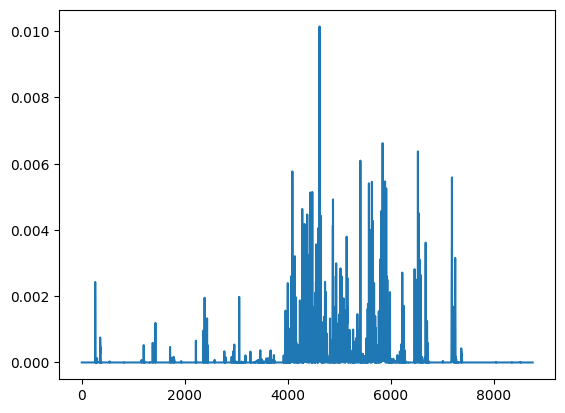

In [ ]:
import numpy as np
x=np.load(r'C:\Users\Darkrai\Projects\iitk proj\testing_ERA5_Data\site\surface_2025.npz')
pwv=x['total_precipitation'][:,1,1]
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))
plt.plot(pwv)

